First 5 rows:


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680



KPIs:
Total Revenue: 2252607.4127
Average Order Value: 230.1161929410563


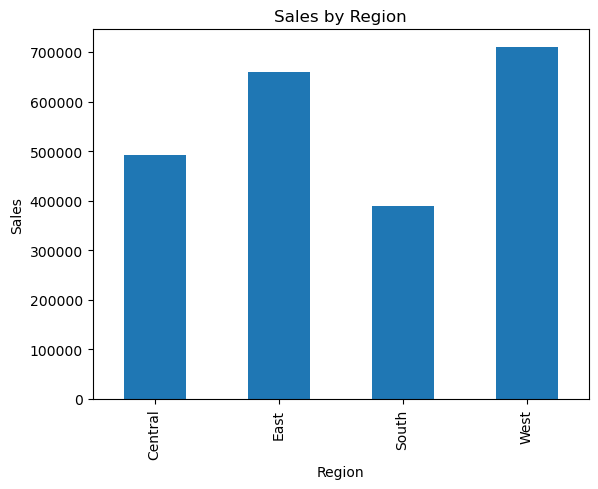

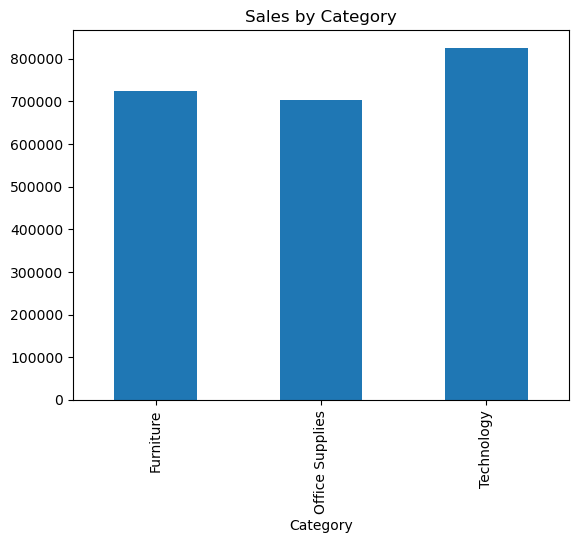

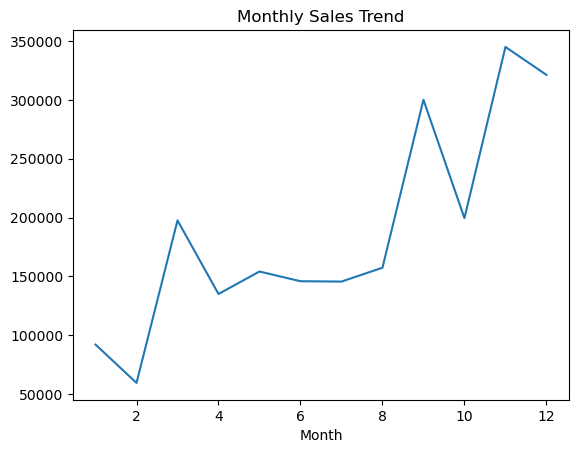

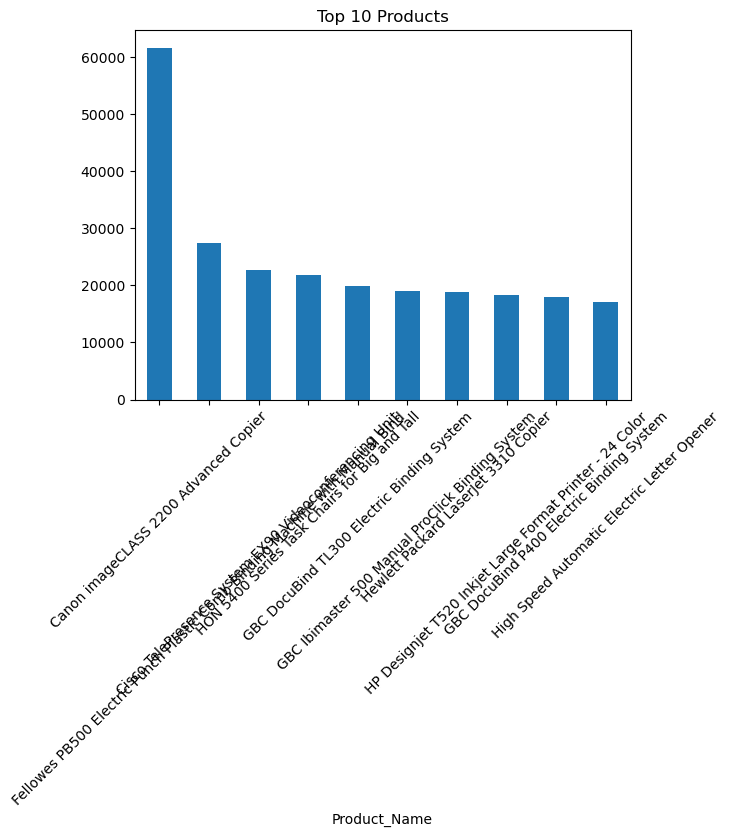

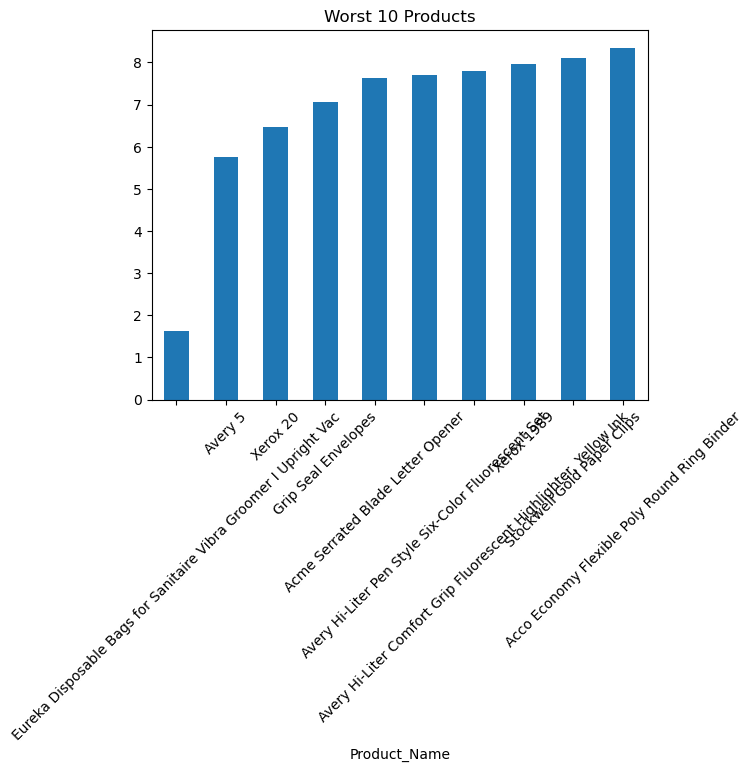


Final Data:


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,10


In [6]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 2: LOAD DATA
# ==============================

df = pd.read_csv("superstore_final_dataset.csv", encoding='latin1')

print("First 5 rows:")
display(df.head())

# ==============================
# STEP 3: CLEAN COLUMN NAMES
# ==============================

df.columns = df.columns.str.strip()

# ==============================
# STEP 4: DATA CLEANING
# ==============================

df = df.dropna()
df = df.drop_duplicates()

# Convert date column
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

# ==============================
# STEP 5: KPIs
# ==============================

total_revenue = df["Sales"].sum()

avg_order_value = df["Sales"].mean()

print("\nKPIs:")
print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)

# ==============================
# STEP 6: REGION-WISE SALES
# ==============================

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure()
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

# ==============================
# STEP 7: CATEGORY ANALYSIS
# ==============================

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure()
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.show()

# ==============================
# STEP 8: TIME ANALYSIS
# ==============================

df["Month"] = df["Order_Date"].dt.month

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

# ==============================
# STEP 9: TOP PRODUCTS
# ==============================

top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products")
plt.xticks(rotation=45)
plt.show()

# ==============================
# STEP 10: WORST PRODUCTS
# ==============================

worst_products = df.groupby("Product_Name")["Sales"].sum().sort_values().head(10)

plt.figure()
worst_products.plot(kind="bar")
plt.title("Worst 10 Products")
plt.xticks(rotation=45)
plt.show()

# ==============================
# STEP 11: FINAL OUTPUT
# ==============================

print("\nFinal Data:")
display(df.head())

In [3]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')